In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from dotenv import load_dotenv
import os

In [ ]:
load_dotenv()

In [ ]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=os.getenv("GOOGLE_API_KEY"),
    temperature=0.7
)

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [4]:
def chat_node(state: ChatState):
    #Take user query from state
    messages = state['messages']

    #send to llm
    response = model.invoke(messages)

    #response store state
    return {'messages': [response]}

In [5]:
checkpointer = MemorySaver()
graph = StateGraph(ChatState)

#add_node
graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

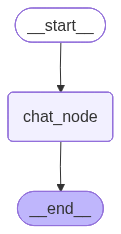

In [6]:
chatbot

In [8]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india?')]
}

chatbot.invoke(initial_state)['messages'][-1].content

ValueError: Checkpointer requires one or more of the following 'configurable' keys: thread_id, checkpoint_ns, checkpoint_id

In [ ]:
thread_id = '1'

while True:
    user_messages = input('Type here:- ')
    print('User:',user_messages)
    if user_messages.strip().lower() in ['exit', 'quit', 'bye']:
        break
    
    config = {'configurable': {'thread_id': thread_id}}
    response = chatbot.invoke({'messages': [HumanMessage(content=user_messages)]},config=config)
    print('AI:', response['messages'][-1].content)

User: Hi
AI: How can I assist you today?
User: my name is nitesh
AI: Nitesh! Nice to meet you. Is there something on your mind that you'd like to chat about, or would you like some company for a bit?
User: what is my name
AI: Your name is Nitesh. We already established that earlier!
User: add 10to 100
AI: 100 + 10 = 110
User: add 25 in result
AI: So, we had:

100 + 10 = 110

And now, let's add 25 to that result:

110 + 25 = 135
User: exit


In [ ]:
#Persistance :- store the data somewhere, database or RAM
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='228975f2-fd5e-48aa-a6df-a5700ec937fa'), AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:latest', 'created_at': '2026-05-17T16:22:17.8215741Z', 'done': True, 'done_reason': 'stop', 'total_duration': 47912960700, 'load_duration': 40638050300, 'prompt_eval_count': 26, 'prompt_eval_duration': 3614097700, 'eval_count': 8, 'eval_duration': 1299847600, 'model_name': 'llama3.2:latest'}, id='lc_run--019e36be-1ea7-7522-9212-0a22212a7341-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34}), HumanMessage(content='my name is nitesh', additional_kwargs={}, response_metadata={}, id='017168a5-00a3-4c17-8096-ef57ba205c02'), AIMessage(content="Nitesh! Nice to meet you. Is there something on your mind that you'd like to chat about, or would you like some company for a bit